<a href="https://colab.research.google.com/github/JWasonga/Python-Projects/blob/Applied_Statistics_and_Econometrics-_Portfolio/1_EDA_%26_Data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Data Set

The dataset augmented with rainfall, climate, and fertilizer data relevant to India. The key attributes are:

**.** **N:** Nitrogen in Soil.

**.** **P:** Phosphorous in Soil.

**.** **K:** Pottasium in Soil.

**.** **Temperature:**

**.** **Humidity:** (%)

**.** **Rainfall:** (mm)

# Data Preprocessing

In [ ]:
#Import warnings library to avoid warnings
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [ ]:
import pandas as pd

data = pd.read_csv('crop_data1.csv')

data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
data1 = pd.read_csv('crop_data2.csv')

data1.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
#Sanity check
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [ ]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1796 entries, 0 to 1795
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            1796 non-null   int64  
 1   P            1796 non-null   int64  
 2   K            1796 non-null   int64  
 3   temperature  1796 non-null   float64
 4   humidity     1796 non-null   float64
 5   ph           1796 non-null   float64
 6   rainfall     1796 non-null   float64
 7   label        1796 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 112.4+ KB


In [ ]:
#calculating data shape
data.shape

(2200, 8)

In [ ]:
data1.shape

(1796, 8)

In [ ]:
#Find missing values
data.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [ ]:
data1.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [ ]:
#Finding duplicates
data.duplicated().sum()

np.int64(0)

In [ ]:
data1.duplicated().sum()

np.int64(103)

In [ ]:
#Fix Duplicates
data1.drop_duplicates(subset = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'], keep = "first", inplace = True)
print(data1.duplicated().sum())

0


In [ ]:
#Identifying Garbage Values
for i in data.select_dtypes(include = 'object').columns:
  print(data[i].value_counts())
  print('***'*10)

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64
******************************


In [ ]:
for i in data1.select_dtypes(include = 'object').columns:
  print(data1[i].value_counts())
  print('***'*10)

label
rice          139
Soyabeans     130
maize         119
banana        106
beans         100
groundnuts    100
peas          100
cowpeas       100
mango         100
grapes        100
watermelon    100
apple         100
orange        100
cotton        100
coffee        100
Jackfruit      25
Sugarcane      25
Groundnut      25
Arecanut       24
Name: count, dtype: int64
******************************


# Exploratory Data Analysis

We are using the dataset which contains the features named as [N,P,K,temperature,humidity,ph,rainfall,label] for training the model.

In [ ]:
#Descriptive statistics
data.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [ ]:
#Transposing the data
data.describe().T

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


In [ ]:
data1.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,1693.000000,1693.000000,1693.000000,1693.000000,1693.000000,1693.000000,1693.000000
mean,53.490254,56.989959,54.191376,24.846083,66.346258,6.443719,103.179210
std,37.615976,34.224323,56.935865,4.883818,23.858660,0.880423,54.901562
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,5.314507
25%,22.000000,35.000000,20.000000,21.975968,52.127394,5.864430,67.727773
50%,39.000000,51.000000,31.000000,25.031496,77.729311,6.364135,94.002872
75%,89.000000,71.000000,53.000000,27.864013,83.882662,6.944640,118.258344
max,140.000000,145.000000,205.000000,41.948657,95.326860,9.935091,346.216891


In [ ]:
data1.describe().T

,count,mean,std,min,25%,50%,75%,max
N,1693.0,53.490254,37.615976,0.000000,22.000000,39.000000,89.000000,140.000000
P,1693.0,56.989959,34.224323,5.000000,35.000000,51.000000,71.000000,145.000000
K,1693.0,54.191376,56.935865,5.000000,20.000000,31.000000,53.000000,205.000000
temperature,1693.0,24.846083,4.883818,8.825675,21.975968,25.031496,27.864013,41.948657
humidity,1693.0,66.346258,23.858660,14.258040,52.127394,77.729311,83.882662,95.326860
ph,1693.0,6.443719,0.880423,3.504752,5.864430,6.364135,6.944640,9.935091
rainfall,1693.0,103.179210,54.901562,5.314507,67.727773,94.002872,118.258344,346.216891


In [ ]:
#descriptive statistics of object column
data.describe(include = 'object')

,label
count,2200
unique,22
top,rice
freq,100


In [ ]:
data1.describe(include = 'object')

,label
count,1693
unique,19
top,rice
freq,139


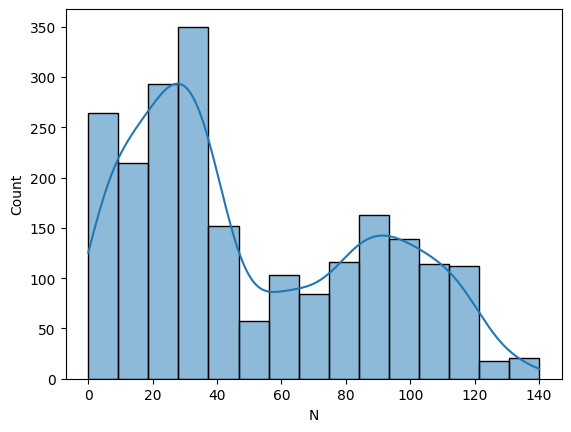

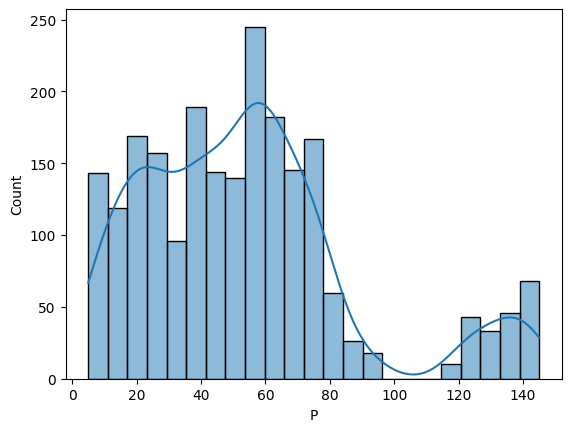

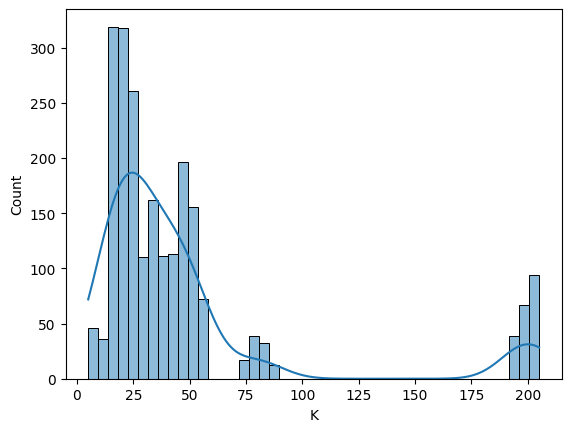

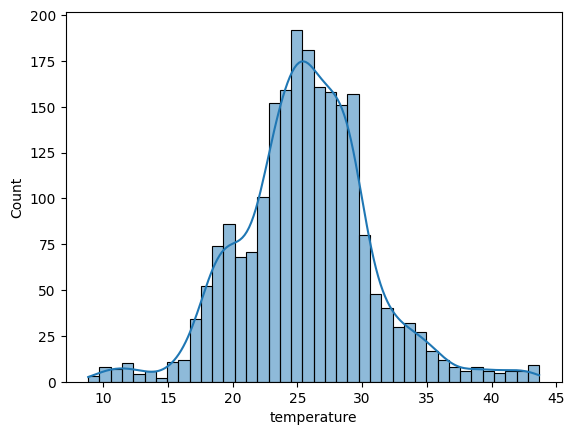

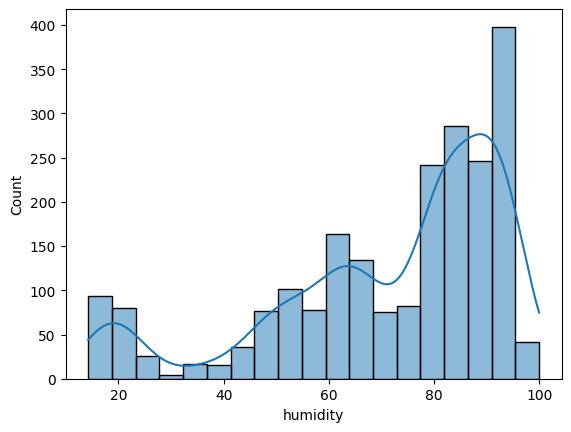

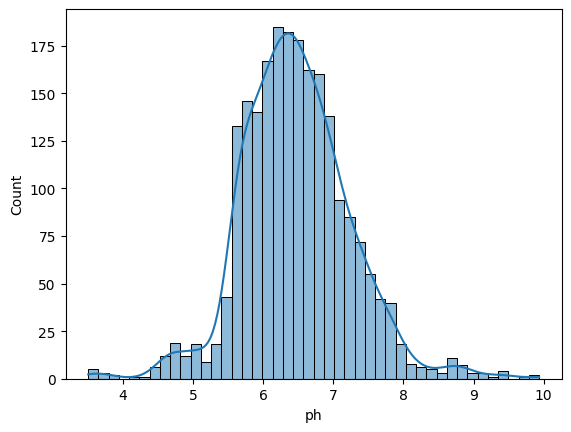

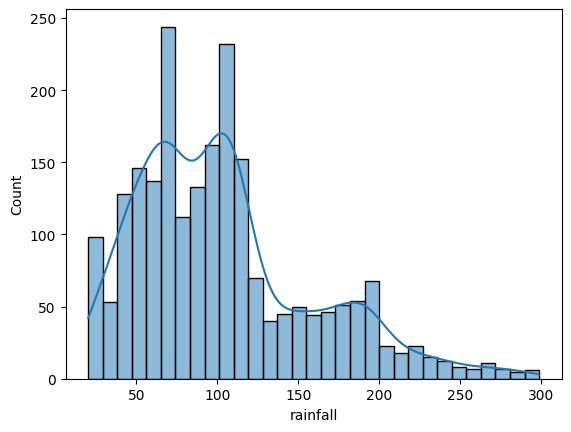

In [ ]:
#histogram to depict the distribution
import seaborn as sns
import matplotlib.pyplot as plt
for i in data.select_dtypes(include = ['number']).columns:
  sns.histplot(data = data, x=i, kde = True)
  plt.show()

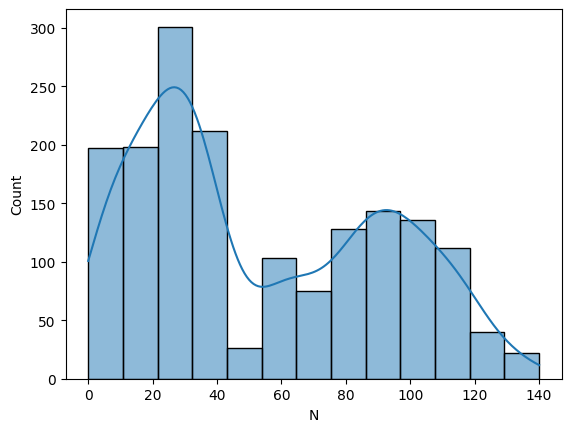

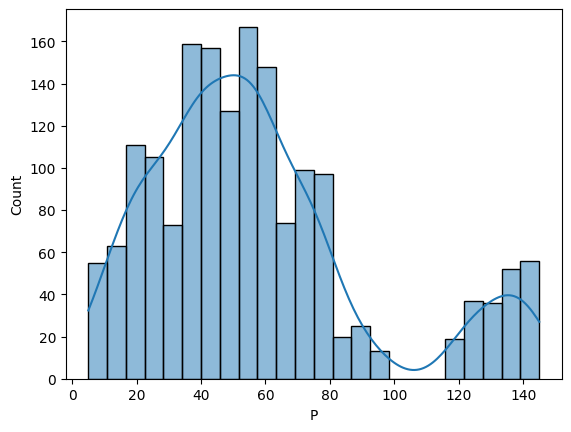

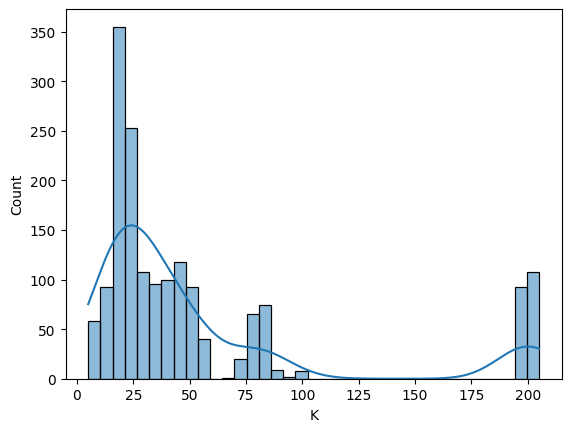

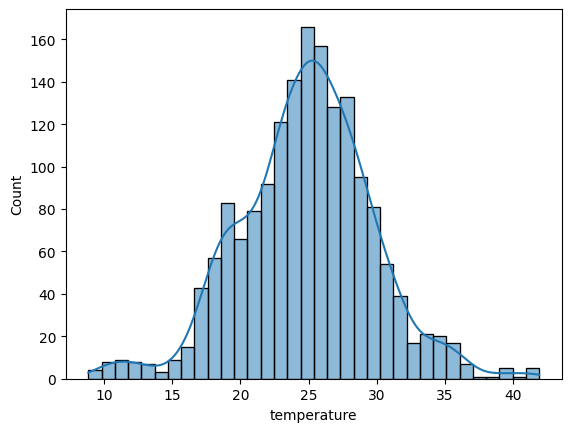

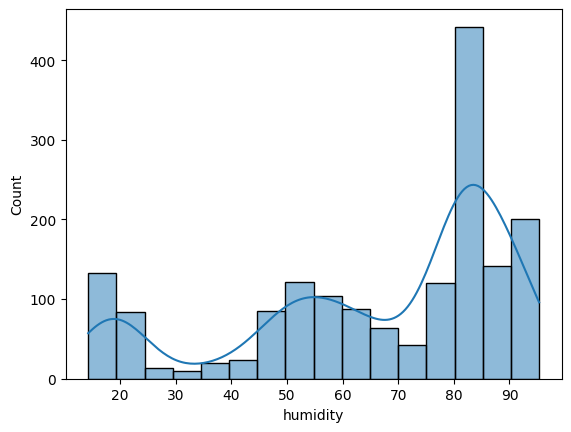

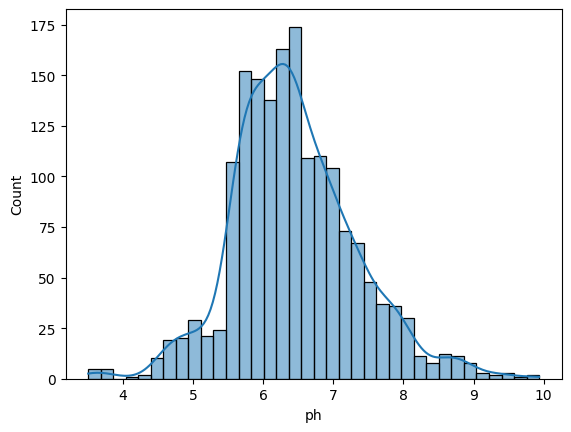

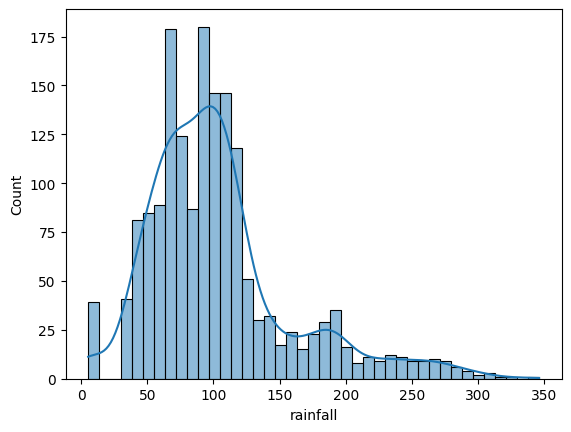

In [ ]:
for i in data1.select_dtypes(include = ['number']).columns:
  sns.histplot(data = data1, x=i, kde = True)
  plt.show()

# Calculating Z-scores to check the Outliers

In [ ]:
from scipy import stats
import numpy as np
z_scores = stats.zscore(data.select_dtypes(include=['number']))
abs_z_scores = np.abs(z_scores)
outliers = (abs_z_scores > 3).any(axis=1)
data_outliers = data[outliers]
print(data_outliers)

       N   P   K  temperature   humidity        ph    rainfall   label
6     69  55  38    22.708838  82.639414  5.700806  271.324860    rice
12    78  58  44    26.800796  80.886848  5.108682  284.436457    rice
16    85  38  41    21.587118  82.788371  6.249051  276.655246    rice
19    88  35  40    23.579436  83.587603  5.853932  291.298662    rice
26    97  59  43    26.359272  84.044036  6.286500  271.358614    rice
...   ..  ..  ..          ...        ...       ...         ...     ...
1758  40  49  47    42.933686  91.175675  6.501521  246.361327  papaya
1761  59  62  49    43.360515  93.351916  6.941497  114.778071  papaya
1766  63  58  50    43.037143  94.642890  6.720744   41.585659  papaya
1778  35  68  45    42.936054  90.094481  6.612430  234.846611  papaya
1797  35  67  49    41.313301  91.150880  6.617067  239.742755  papaya

[171 rows x 8 columns]


# Checking the Quantile values for classifying outliers

In [ ]:
def whisker(col):
    q1,q3 = np.percentile(col, [25, 75])
    iqr = q3-q1
    lw = q1 - 1.5 * iqr
    uw = q1 + 1.5 * iqr
    return lw, uw


In [ ]:
for i in ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']:
  lw, uw = whisker(data[i])
  print(f'\t\t\tOutliers\n*******************************************************************************************************************')
  print(f' {i}-lower:{lw}\tt{i}-upper:{uw}\n')


			Outliers
*******************************************************************************************************************
 N-lower:-73.875	tN-upper:115.875

			Outliers
*******************************************************************************************************************
 P-lower:-32.0	tP-upper:88.0

			Outliers
*******************************************************************************************************************
 K-lower:-23.5	tK-upper:63.5

			Outliers
*******************************************************************************************************************
 temperature-lower:14.080955682499999	ttemperature-upper:31.457793582500003

			Outliers
*******************************************************************************************************************
 humidity-lower:15.731725873750001	thumidity-upper:104.79217973125

			Outliers
************************************************************************************************************

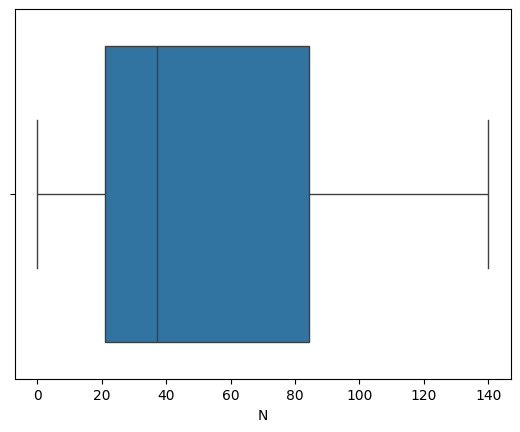

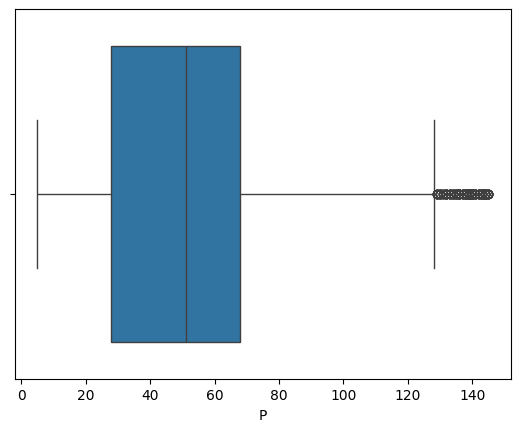

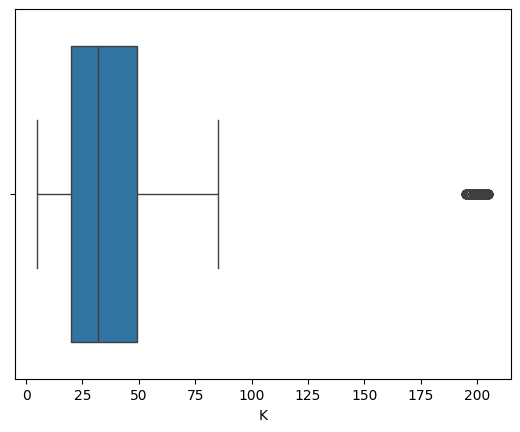

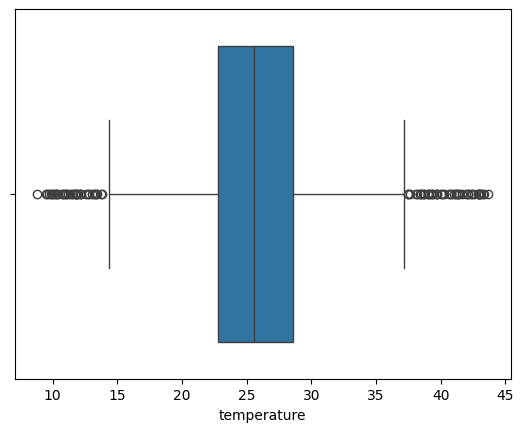

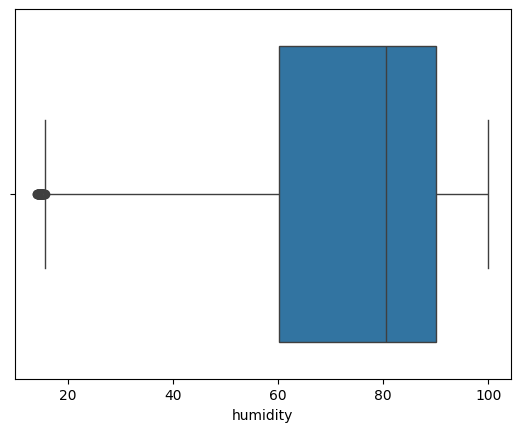

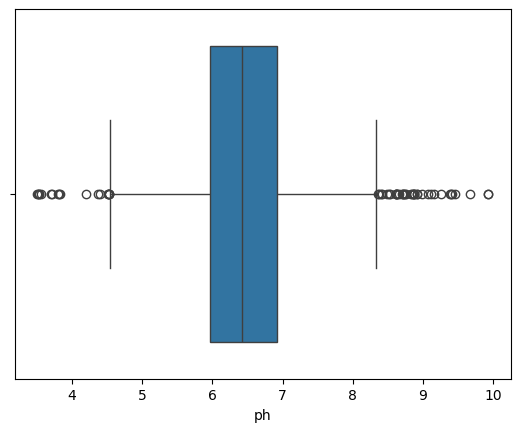

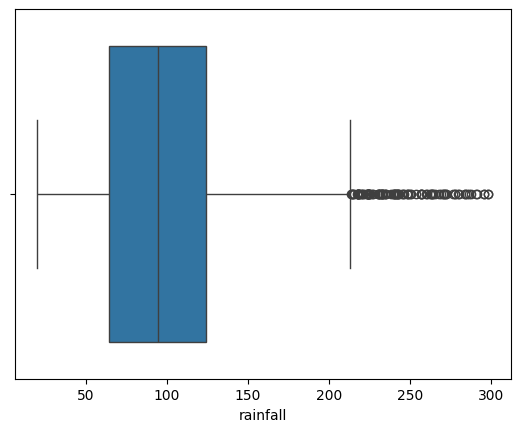

In [ ]:
#Box plot to identify the distribution and outliers
import seaborn as sns
from matplotlib import pyplot as plt
for i in data.select_dtypes(include = ['number']).columns:
  sns.boxplot(data = data, x = i)
  plt.show()

In [ ]:
from scipy import stats
import numpy as np
z_scores = stats.zscore(data1.select_dtypes(include=['number']))
abs_z_scores = np.abs(z_scores)
outliers = (abs_z_scores > 3).any(axis=1)
data1_outliers = data1[outliers]
print(data1_outliers)

       N   P   K  temperature   humidity        ph    rainfall      label
6     69  55  38    22.708838  82.639414  5.700806  271.324860       rice
12    78  58  44    26.800796  80.886848  5.108682  284.436457       rice
16    85  38  41    21.587118  82.788371  6.249051  276.655246       rice
19    88  35  40    23.579436  83.587603  5.853932  291.298662       rice
26    97  59  43    26.359272  84.044036  6.286500  271.358614       rice
...   ..  ..  ..          ...        ...       ...         ...        ...
1715  98  22  83    26.357653  82.477936  6.422285  318.180614   Arecanut
1717  97  27  89    27.005186  84.784360  7.199607  275.519913   Arecanut
1720  91  27  86    23.465145  82.096218  5.899593  307.440414   Arecanut
1730  58  49  89    27.663592  74.735938  6.695659  274.249224  Jackfruit
1739  49  31  75    26.544250  79.631016  7.403485  273.713418  Jackfruit

[66 rows x 8 columns]


In [ ]:
for i in ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']:
  lw, uw = whisker(data1[i])
  print(f'\t\t\tOutliers\n*******************************************************************************************************************')
  print(f' {i}-lower:{lw}\tt{i}-upper:{uw}\n')

			Outliers
*******************************************************************************************************************
 N-lower:-78.5	tN-upper:122.5

			Outliers
*******************************************************************************************************************
 P-lower:-19.0	tP-upper:89.0

			Outliers
*******************************************************************************************************************
 K-lower:-29.5	tK-upper:69.5

			Outliers
*******************************************************************************************************************
 temperature-lower:13.143899725000002	ttemperature-upper:30.808035894999996

			Outliers
*******************************************************************************************************************
 humidity-lower:4.494492014999999	thumidity-upper:99.76029640499999

			Outliers
***************************************************************************************************************

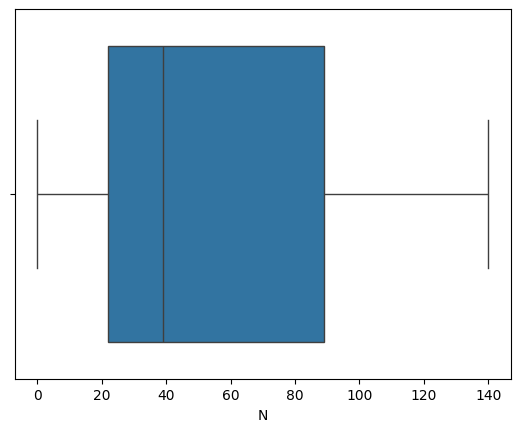

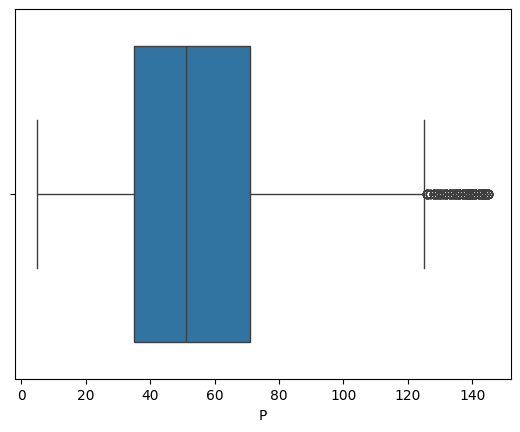

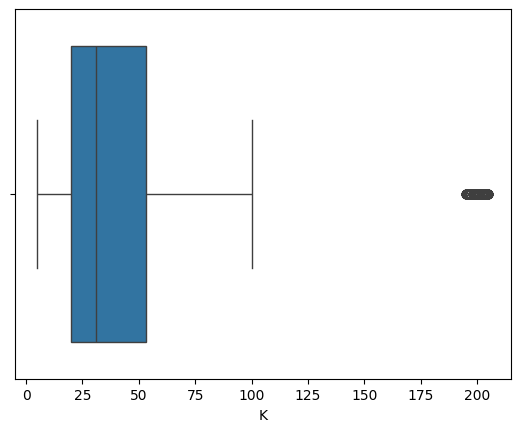

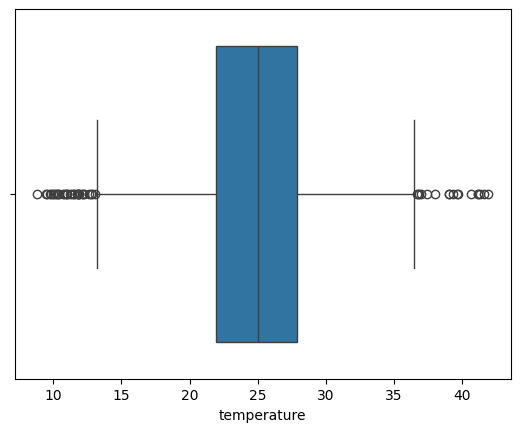

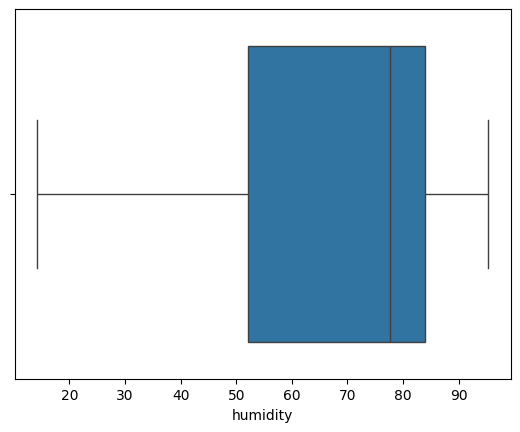

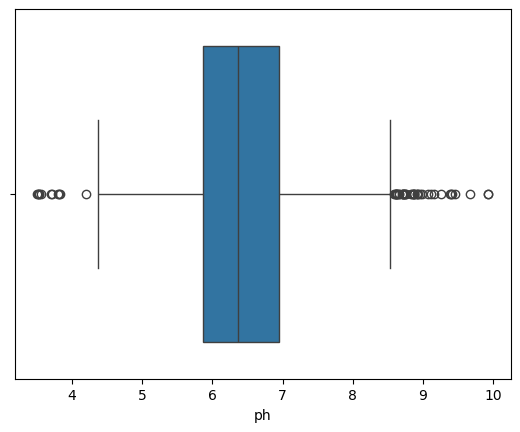

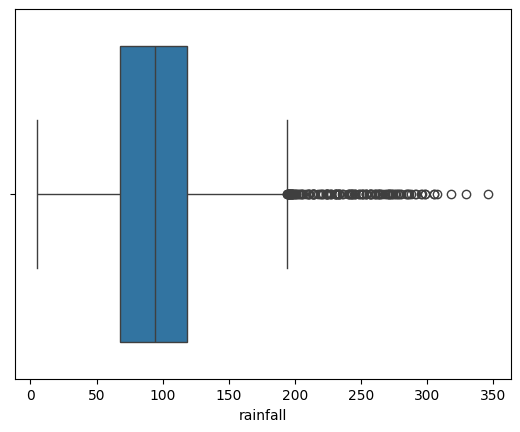

In [ ]:
for i in data1.select_dtypes(include = 'number').columns:
  sns.boxplot(data= data1, x=i)
  plt.show()

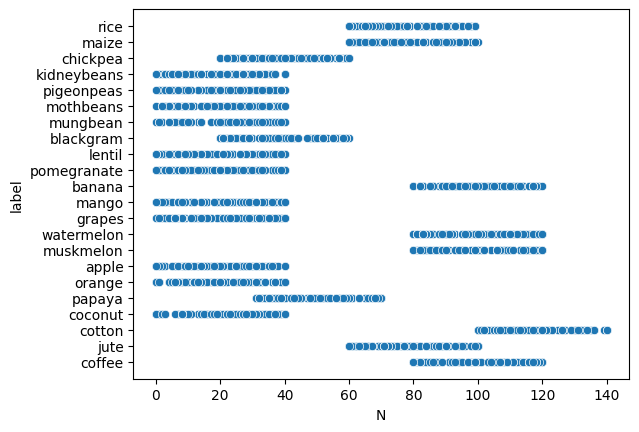

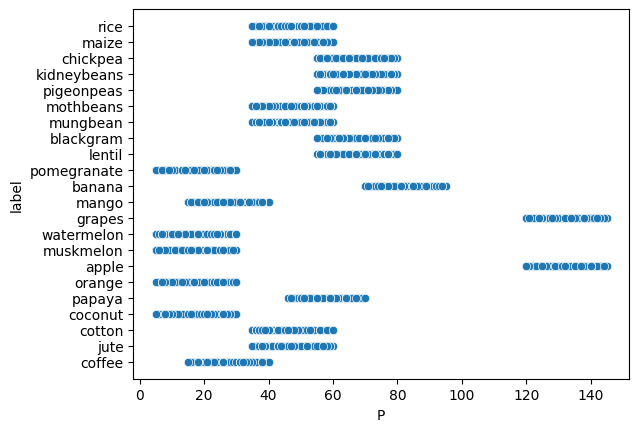

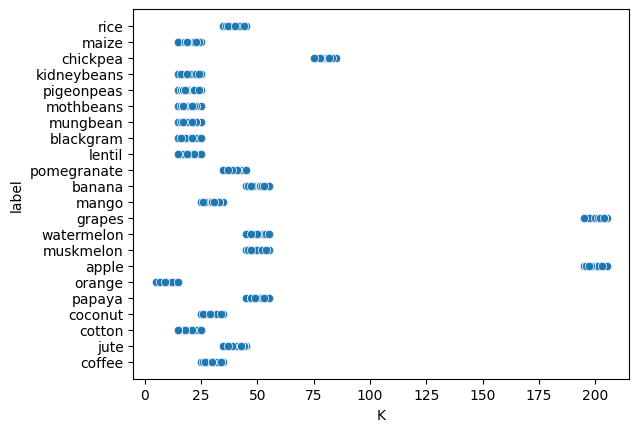

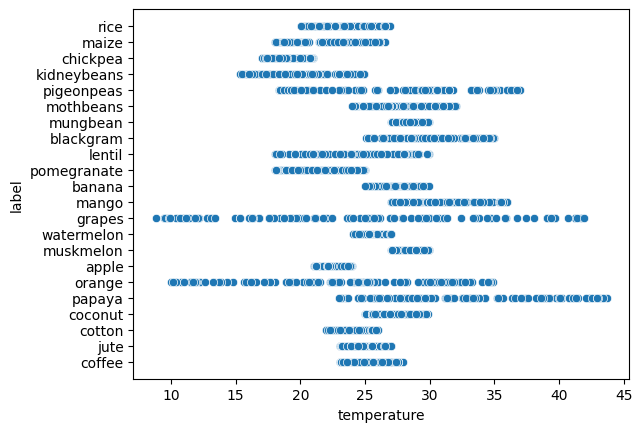

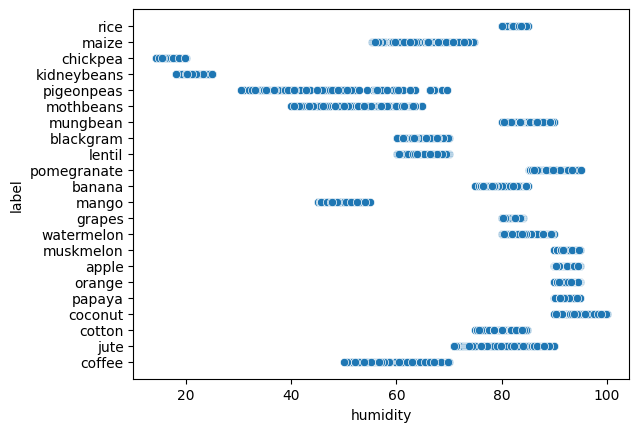

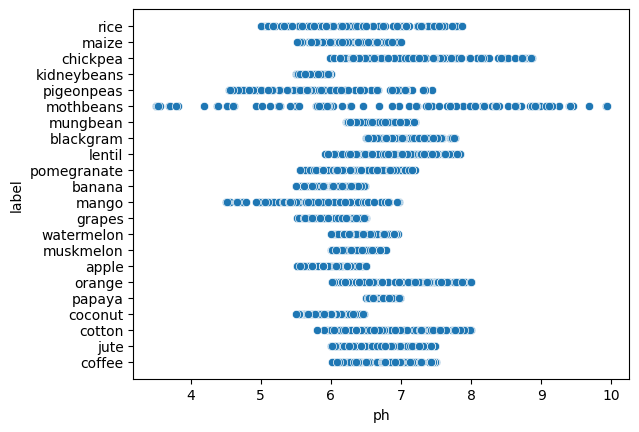

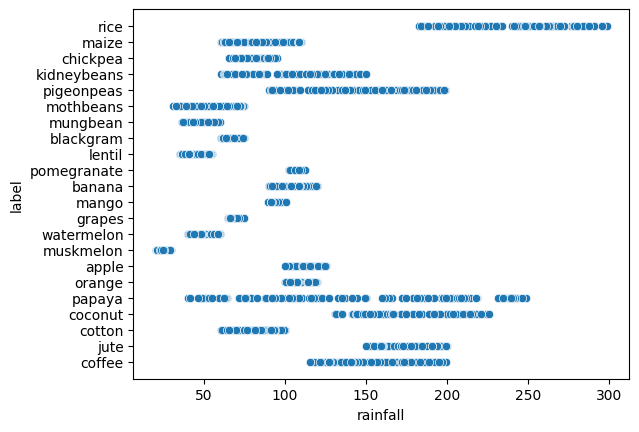

In [ ]:
#Scatter plot to understand the relationship between features and label
for i in ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']:
  sns.scatterplot(data = data, x =i, y= 'label')
  plt.show()

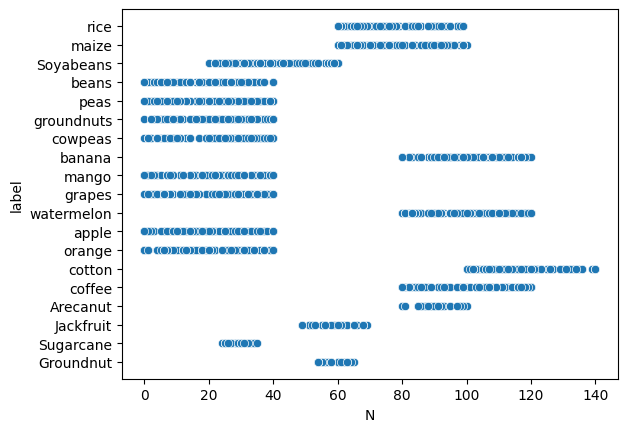

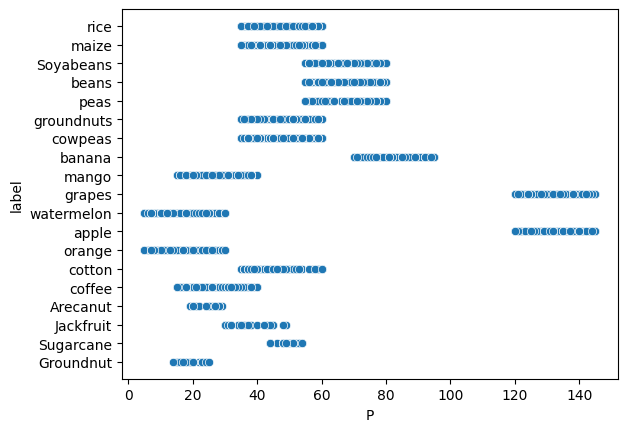

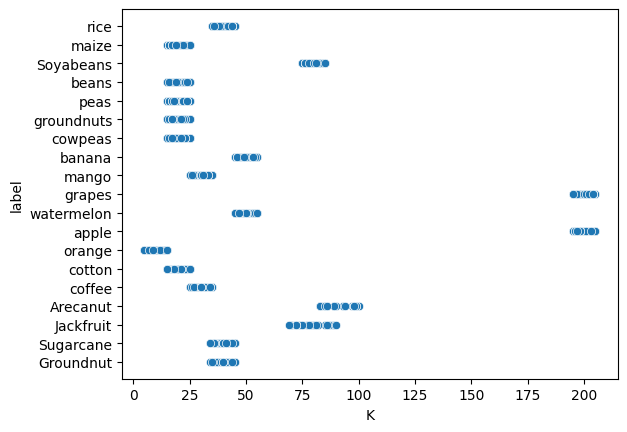

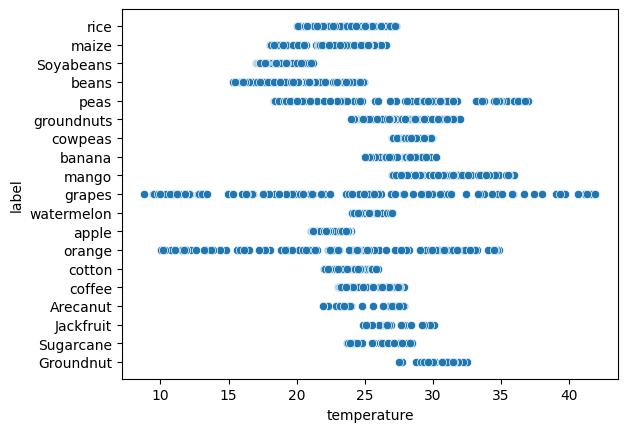

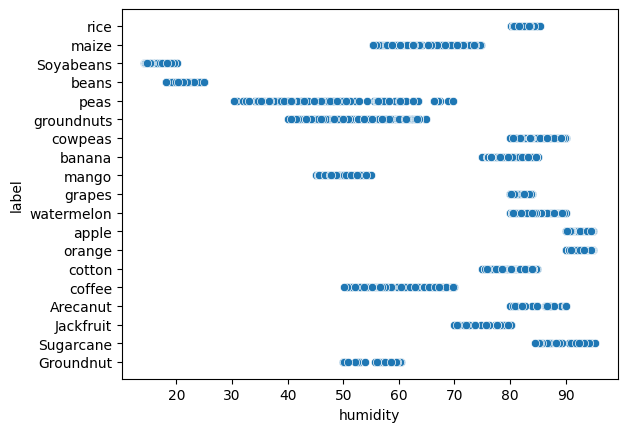

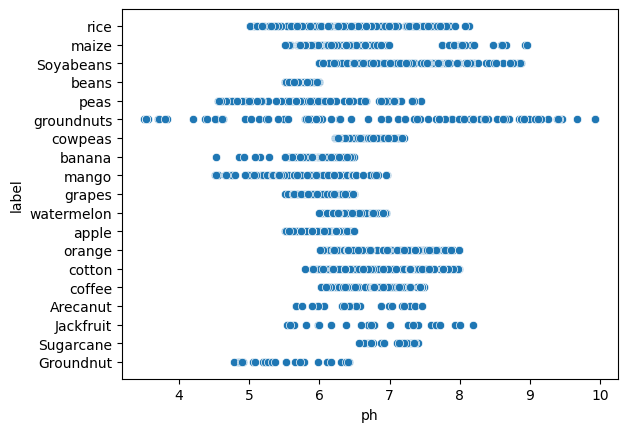

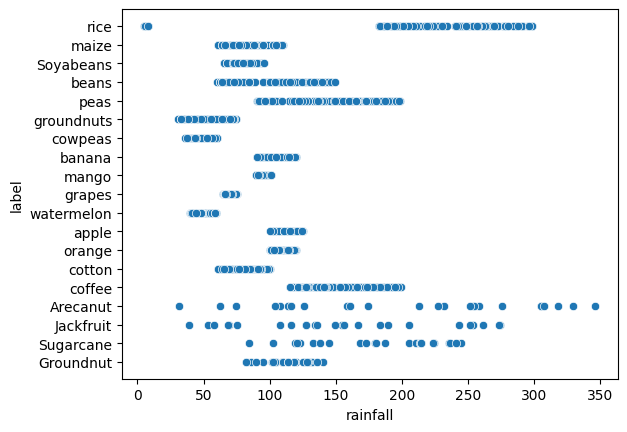

In [ ]:
for i in ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']:
  sns.scatterplot(data = data1, x= i, y= 'label')
  plt.show()

In [ ]:
#Correlation with heatmap to intepret the relation and multicollinearity
set1 = data.select_dtypes(include = 'number').corr()
set1

,N,P,K,temperature,humidity,ph,rainfall
N,1.000000,-0.231460,-0.140512,0.026504,0.190688,0.096683,0.059020
P,-0.231460,1.000000,0.736232,-0.127541,-0.118734,-0.138019,-0.063839
K,-0.140512,0.736232,1.000000,-0.160387,0.190859,-0.169503,-0.053461
temperature,0.026504,-0.127541,-0.160387,1.000000,0.205320,-0.017795,-0.030084
humidity,0.190688,-0.118734,0.190859,0.205320,1.000000,-0.008483,0.094423
ph,0.096683,-0.138019,-0.169503,-0.017795,-0.008483,1.000000,-0.109069
rainfall,0.059020,-0.063839,-0.053461,-0.030084,0.094423,-0.109069,1.000000


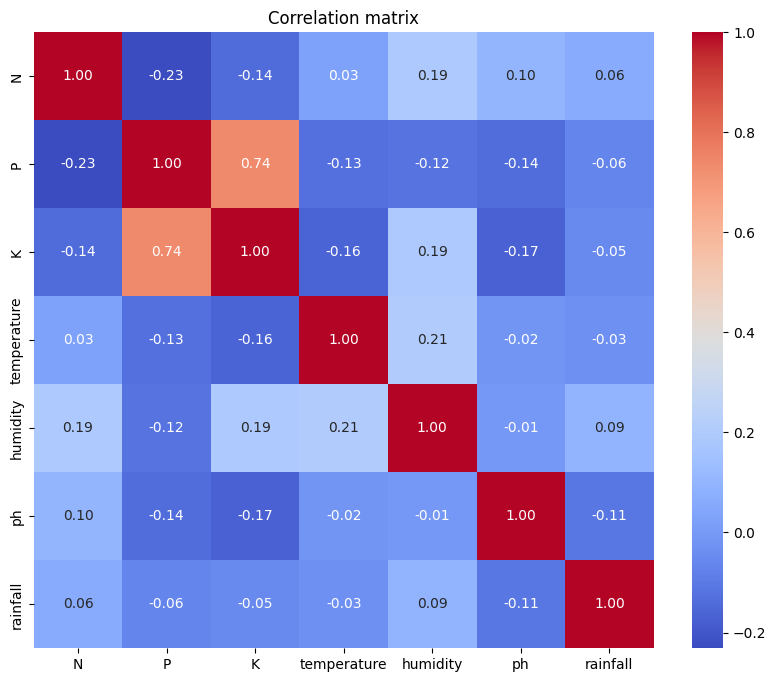

In [ ]:
plt.figure(figsize = (10, 8))
sns.heatmap(set1, annot = True, fmt = '.2f', cmap = 'coolwarm')
plt.title('Correlation matrix')
plt.show()

In [ ]:
set2 = data1.select_dtypes(include = 'number').corr()
set2

,N,P,K,temperature,humidity,ph,rainfall
N,1.000000,-0.289825,-0.214300,-0.008545,0.247683,0.119066,0.119478
P,-0.289825,1.000000,0.803088,-0.187071,0.038763,-0.219521,-0.060817
K,-0.214300,0.803088,1.000000,-0.169719,0.220605,-0.139086,-0.047388
temperature,-0.008545,-0.187071,-0.169719,1.000000,0.179388,-0.128819,-0.021486
humidity,0.247683,0.038763,0.220605,0.179388,1.000000,0.004336,0.047791
ph,0.119066,-0.219521,-0.139086,-0.128819,0.004336,1.000000,-0.069806
rainfall,0.119478,-0.060817,-0.047388,-0.021486,0.047791,-0.069806,1.000000


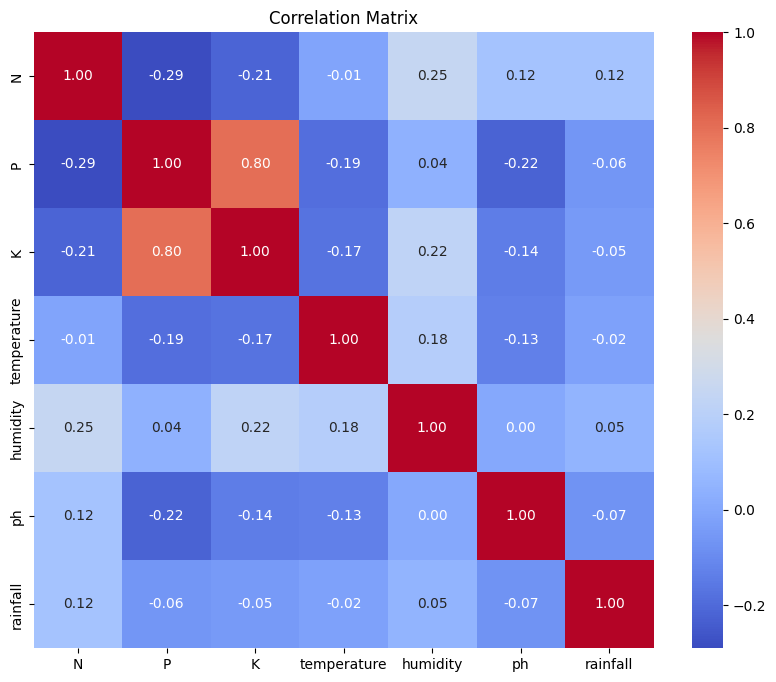

In [ ]:
plt.figure(figsize = (10, 8))
sns.heatmap(set2, annot=True, fmt='.2f', cmap = 'coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
data.select_dtypes(include = 'number').columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'], dtype='object')

In [ ]:
data1.select_dtypes(include = 'number').columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'], dtype='object')

#Feature Engineering

We are merging multiple datasets for better training and performance of the model.

In [ ]:
#Merging datasets
import pandas as pd

merged_data = pd.concat([data,data1], axis = 0)
merged_data.shape

(3893, 8)

In [ ]:
merged_data

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
1791,61,18,41,31.042050,50.181397,5.360749,128.902109,Groundnut
1792,58,24,45,27.527798,52.089167,4.895913,135.823036,Groundnut
1793,54,20,44,30.690720,50.919810,6.111688,128.034877,Groundnut
1794,54,17,40,31.492970,53.925175,5.519773,118.555197,Groundnut


In [ ]:
#Checking fro duplicated values
merged_data.duplicated().sum()

np.int64(663)

In [ ]:
#Checking for null values
merged_data.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [ ]:
#Removing duplicates
merged_data.drop_duplicates(subset = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'], keep = 'first', inplace = True)

merged_data.duplicated().sum()

np.int64(0)

In [ ]:
final_dataset = merged_data
final_dataset

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
1791,61,18,41,31.042050,50.181397,5.360749,128.902109,Groundnut
1792,58,24,45,27.527798,52.089167,4.895913,135.823036,Groundnut
1793,54,20,44,30.690720,50.919810,6.111688,128.034877,Groundnut
1794,54,17,40,31.492970,53.925175,5.519773,118.555197,Groundnut


In [ ]:
final_dataset.to_csv('final_dataset', index =False)
print("data saved sucessfully!")

data saved sucessfully!
